In [ ]:
# 1 - data cleaning 
# this notebooks purpose is to take the new data (data_new_2) and add to the metadata.csv
# and see how the current best model performs. The model performed similarly but having weird issues 
# possibly due to uneven distributions. 
# We identified several issues that will be adressed in other notebooks:
#   -several panels appearing in data and data_new_2 have different leveling scores
#   -the distribution of the data is uneven, and we need to investigate if the model performs
#   better on more frequent scores vs rare score like would be expected


### NOTE: panel mislabelling was fixed and the load_metadata now reflects that, so this notebook when
# running wont have mislabeling


In [19]:
# imports

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F

import sys
import os
import importlib
import numpy as np

sys.path.append(os.path.abspath(".."))
from src.build_metadata import build_df_from_data, build_df_from_new_data
from src.data import load_images_from_metadata, filter_images
from src.model import train_random_forest_model

In [20]:
# load all of the data into metadata csv file including the new data (data_new_2))
from src.build_metadata import load_metadata
import importlib
import src.build_metadata as build_metadata

importlib.reload(build_metadata)
build_metadata.load_metadata(
    data_base_dir="../data",
    new_data_base_dir="../data_new",
    new_data_2_base_dir="../data_new_2",
    output_file="metadata.csv",
)

Saved metadata to ../data\metadata.csv
Combined records: 1340


,LevelingScore,Person,DateCollected,ImageType,GSCamera,PanelID,State,FilePath
0,1,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (1...
1,1,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (2...
2,1,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (3...
3,1,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (4...
4,1,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (5...
...,...,...,...,...,...,...,...,...
1335,10,Nicole,7.9.2026,DD,2BDR-9F02,25-154,raw,../data_new_2\10\{leveling-10}_P{Nicole}_D{7.9...
1336,10,Nicole,7.9.2026,DD,2BDR-9F02,25-154,raw,../data_new_2\10\{leveling-10}_P{Nicole}_D{7.9...
1337,10,Nicole,7.9.2026,DD,2BDR-9F02,25-154,flat,../data_new_2\10\{leveling-10}_P{Nicole}_D{7.9...
1338,10,Nicole,7.9.2026,DD,2BDR-9F02,25-154,flat,../data_new_2\10\{leveling-10}_P{Nicole}_D{7.9...


In [21]:
# run the current best model to see how it performs with new data added (data_new_2)

In [ ]:
# get the data
data = load_images_from_metadata("../data/metadata.csv", crop_fraction = .4, use_cv2=True)

data_standards = filter_images(data, ImageType = "STD", State = "flat", DateCollected = ["6.2.2026", "6.3.2026", "6.5.2026", "6.8.2026"])
data_real_paint = filter_images(data, ImageType = "DD", State = "flat")

KeyboardInterrupt: 

: 

In [ ]:
#
# now first lets print how many unique panels we have in data_real_paint and what levelign score those correspond to
#
import pandas as pd

# Build dataframe
df = pd.DataFrame([
    {
        "PanelID": str(d["PanelID"]),
        "LevelingScore": d["LevelingScore"]
    }
    for d in data_real_paint
])

# Remove missing panel IDs
df = df[df["PanelID"] != "nan"]

print("\n" + "=" * 70)
print("UNIQUE PANELS PER LEVELING SCORE")
print("=" * 70)

score_to_panels = (
    df.groupby("LevelingScore")["PanelID"]
      .unique()
)

for score in sorted(score_to_panels.index):

    panels = sorted(score_to_panels[score])

    print(f"\nScore {score}")
    print(f"Unique Panels: {len(panels)}")
    print(", ".join(panels))

print("\n" + "=" * 70)
print("PANELS APPEARING IN MULTIPLE SCORES")
print("=" * 70)

panel_to_scores = (
    df.groupby("PanelID")["LevelingScore"]
      .unique()
)

repeated_count = 0

for panel, scores in sorted(panel_to_scores.items()):

    clean_scores = sorted(int(s) for s in scores)

    if len(clean_scores) > 1:
        repeated_count += 1

        score_str = ", ".join(map(str, clean_scores))

        print(f"{panel:10s} -> Scores [{score_str}]")

print(f"\nTotal repeated panels: {repeated_count}")


UNIQUE PANELS PER LEVELING SCORE

Score 1
Unique Panels: 3
25-108, 25-111, 25-130

Score 2
Unique Panels: 12
25-100, 25-101, 25-108, 25-111, 25-112, 25-114, 25-121, 25-122, 25-123, 25-129, 25-138, 25-139

Score 3
Unique Panels: 12
25-100, 25-102, 25-103, 25-109, 25-113, 25-116, 25-117, 25-120, 25-126, 25-127, 25-137, 25-142

Score 4
Unique Panels: 6
25-106, 25-110, 25-115, 25-118, 25-119, 25-145

Score 5
Unique Panels: 7
25-110, 25-115, 25-133, 25-140, 25-143, 25-144, 25-150

Score 6
Unique Panels: 5
25-131, 25-132, 25-136, 25-141, 25-144

Score 7
Unique Panels: 2
25-107, 25-128

Score 8
Unique Panels: 8
25-104, 25-105, 25-107, 25-125, 25-132, 25-146, 25-147, 25-148

Score 9
Unique Panels: 6
25-105, 25-124, 25-134, 25-135, 25-147, 25-149

Score 10
Unique Panels: 2
25-134, 25-154

PANELS APPEARING IN MULTIPLE SCORES
25-100     -> Scores [2, 3]
25-105     -> Scores [8, 9]
25-107     -> Scores [7, 8]
25-108     -> Scores [1, 2]
25-110     -> Scores [4, 5]
25-111     -> Scores [1, 2]
25-1

In [ ]:
#
# insight: we have multiple unique panels appearing under multiple lelevling scores, big issue, need to figure this out
#

In [ ]:
# current best model with the new data added (data_new_2) - reports best mae for epoch, go down
# further for the actual best model code to use
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split, GroupKFold
from collections import Counter, defaultdict

torch.manual_seed(42)
np.random.seed(42)

# =========================
# ✅ DATA PREP
# =========================
def prepare_data_with_groups(data, img_size=(128, 128)):
    X, y, groups = [], [], []

    for d in data:
        img = d["image"].astype(np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)

        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=img_size,
            mode="bilinear", align_corners=False
        ).squeeze(0)

        X.append(img)
        y.append(d["LevelingScore"])
        groups.append(d.get("PanelID", None))

    return X, np.array(y), np.array(groups)

X_real, y_real, groups_real = prepare_data_with_groups(data_real_paint)
X_std, y_std, _ = prepare_data_with_groups(data_standards)

# =========================
# ✅ PANEL SPLIT
# =========================
unique_panels = np.unique(groups_real)

train_panels, test_panels = train_test_split(
    unique_panels, test_size=0.2, random_state=42
)

train_idx = np.isin(groups_real, train_panels)
test_idx  = np.isin(groups_real, test_panels)

X_train_real = [X_real[i] for i in range(len(X_real)) if train_idx[i]]
y_train_real = y_real[train_idx]
groups_train = groups_real[train_idx]

X_test = [X_real[i] for i in range(len(X_real)) if test_idx[i]]
y_test = y_real[test_idx]
groups_test = groups_real[test_idx]

# =========================
# ✅ TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.RandomResizedCrop(128, scale=(0.95, 1.0)),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# =========================
# ✅ MODEL
# =========================
class WaveletCNN(nn.Module):
    def __init__(self, num_blocks=5, base_channels=16):
        super().__init__()

        self.pool = nn.AvgPool2d(2)

        layers = []
        in_channels = 1
        channels = base_channels

        for i in range(num_blocks):
            layers += [
                nn.Conv2d(in_channels, channels, 3, padding=1),
                nn.BatchNorm2d(channels),
                nn.ReLU(),
                nn.Conv2d(channels, channels, 3, padding=1),
                nn.ReLU()
            ]

            if i < num_blocks - 1:
                layers.append(nn.MaxPool2d(2))

            in_channels = channels
            channels *= 2

        layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        self.features = nn.Sequential(*layers)

        self.regressor = nn.Sequential(
            nn.Linear(in_channels + 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x_low1 = self.pool(x)
        x_low2 = self.pool(x_low1)

        m0 = x.mean(dim=[2,3])
        m1 = x_low1.mean(dim=[2,3])
        m2 = x_low2.mean(dim=[2,3])

        wavelet_feats = torch.cat([m0, m1, m2], dim=1)

        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)

        combined = torch.cat([feats, wavelet_feats], dim=1)

        return self.regressor(combined)

# =========================
# ✅ SAMPLER
# =========================
def get_weighted_sampler(y):
    counter = Counter(y)
    weights = np.array([1.0 / counter[val] for val in y])
    return torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights),
        replacement=True
    )

# =========================
# ✅ CROSS VALIDATION
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 16
epochs = 10

gkf = GroupKFold(n_splits=5)

cv_maes = []
cv_val_losses = []   # ✅ NEW

for fold, (train_idx_cv, val_idx_cv) in enumerate(
    gkf.split(X_train_real, y_train_real, groups_train)
):
    print(f"\n===== Fold {fold+1} =====")

    X_train_fold = [X_train_real[i] for i in train_idx_cv] + X_std
    y_train_fold = np.concatenate([y_train_real[train_idx_cv], y_std])

    X_val_fold = [X_train_real[i] for i in val_idx_cv]
    y_val_fold = y_train_real[val_idx_cv]

    sampler = get_weighted_sampler(y_train_fold)

    net = WaveletCNN().to(device)
    optimizer = optim.Adam(net.parameters(), lr=5e-4)
    criterion = nn.L1Loss()

    best_mae = float("inf")
    best_val_loss = float("inf")   # ✅ NEW

    for epoch in range(epochs):
        net.train()

        idx_list = list(sampler)

        for i in range(0, len(idx_list), batch_size):
            idx = idx_list[i:i+batch_size]

            imgs = torch.stack([
                train_transform(X_train_fold[j]) for j in idx
            ]).to(device)

            labels = torch.tensor(y_train_fold[idx]).float().to(device)

            optimizer.zero_grad()
            outputs = net(imgs).squeeze()

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # ✅ VALIDATION
        net.eval()
        X_val_proc = torch.stack(
            [test_transform(img) for img in X_val_fold]
        ).to(device)

        with torch.no_grad():
            outputs = net(X_val_proc).squeeze()
            preds = outputs.cpu().numpy()

        mae = np.mean(np.abs(y_val_fold - preds))

        labels = torch.tensor(y_val_fold).float().to(device)
        val_loss = criterion(outputs, labels).item()

        best_mae = min(best_mae, mae)
        best_val_loss = min(best_val_loss, val_loss)   # ✅ NEW

    print(f"Fold {fold+1} MAE: {best_mae:.3f}")
    cv_maes.append(best_mae)
    cv_val_losses.append(best_val_loss)   # ✅ NEW

print("\nCV Mean MAE:", np.mean(cv_maes))
print("CV Mean Val Loss:", np.mean(cv_val_losses))   # ✅ NEW

# =========================
# ✅ FINAL TRAIN + TEST
# =========================
print("\n===== FINAL TRAIN + TEST =====")

X_train = X_train_real + X_std
y_train = np.concatenate([y_train_real, y_std])

sampler = get_weighted_sampler(y_train)

net = WaveletCNN().to(device)
optimizer = optim.Adam(net.parameters(), lr=5e-4)
criterion = nn.L1Loss()

for epoch in range(epochs):
    net.train()

    idx_list = list(sampler)

    for i in range(0, len(idx_list), batch_size):
        idx = idx_list[i:i+batch_size]

        imgs = torch.stack([
            train_transform(X_train[j]) for j in idx
        ]).to(device)

        labels = torch.tensor(y_train[idx]).float().to(device)

        optimizer.zero_grad()
        outputs = net(imgs).squeeze()

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

# ✅ TEST
net.eval()

X_test_proc = torch.stack(
    [test_transform(img) for img in X_test]
).to(device)

with torch.no_grad():
    preds = net(X_test_proc).squeeze().cpu().numpy()

abs_error = np.abs(y_test - preds)

mae = np.mean(abs_error)
w1 = np.mean(abs_error <= 1) * 100
w2 = np.mean(abs_error <= 2) * 100

print(f"\nTEST → MAE={mae:.3f}, ±1={w1:.1f}%, ±2={w2:.1f}%")

# =========================
# ✅ CONSISTENCY METRIC
# =========================
panel_preds = defaultdict(list)

for pred, panel in zip(preds, groups_test):
    panel_preds[panel].append(pred)

stds = []

for panel in panel_preds:
    vals = np.array(panel_preds[panel])
    if len(vals) > 1:
        stds.append(np.std(vals))

mean_std = np.mean(stds)

print(f"Mean per-panel std: {mean_std:.3f}")


===== Fold 1 =====
Fold 1 MAE: 0.793

===== Fold 2 =====
Fold 2 MAE: 0.795

===== Fold 3 =====
Fold 3 MAE: 0.851

===== Fold 4 =====
Fold 4 MAE: 0.759

===== Fold 5 =====
Fold 5 MAE: 0.664

CV Mean MAE: 0.772337908206439
CV Mean Val Loss: 0.7723378539085388

===== FINAL TRAIN + TEST =====

TEST → MAE=1.304, ±1=35.6%, ±2=87.7%
Mean per-panel std: 0.424


In [ ]:
# insights:
# The model trained with the new data (data_new_2) is performing similarly in terms of cross validation
# to the model trained with less data.
# We are observing different performance across the validation folds, some folds perform better, some worse,
# but bradley said its not too different. The test set is quite different though. 
# We also realize that the above code is picking the best epoch mae, and we want to keep things consistant
# so we will run the model just looking at the mae after 10 epochs for each validation fold, just like the final
# train and test set. 
# 
#

In [ ]:
#
# current best mode with new data added (data_new_2) with mae results reported after 10 epochs
#

In [ ]:
# current best model with the new data added (data_new_2) mae results reported after 10 epochs
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split, GroupKFold
from collections import Counter, defaultdict

torch.manual_seed(42)
np.random.seed(42)

# =========================
# ✅ DATA PREP
# =========================
def prepare_data_with_groups(data, img_size=(128, 128)):
    X, y, groups = [], [], []

    for d in data:
        img = d["image"].astype(np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)

        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=img_size,
            mode="bilinear", align_corners=False
        ).squeeze(0)

        X.append(img)
        y.append(d["LevelingScore"])
        groups.append(d.get("PanelID", None))

    return X, np.array(y), np.array(groups)

X_real, y_real, groups_real = prepare_data_with_groups(data_real_paint)
X_std, y_std, _ = prepare_data_with_groups(data_standards)

# =========================
# ✅ PANEL SPLIT
# =========================
unique_panels = np.unique(groups_real)

train_panels, test_panels = train_test_split(
    unique_panels, test_size=0.2, random_state=42
)

train_idx = np.isin(groups_real, train_panels)
test_idx  = np.isin(groups_real, test_panels)

X_train_real = [X_real[i] for i in range(len(X_real)) if train_idx[i]]
y_train_real = y_real[train_idx]
groups_train = groups_real[train_idx]

X_test = [X_real[i] for i in range(len(X_real)) if test_idx[i]]
y_test = y_real[test_idx]
groups_test = groups_real[test_idx]

# =========================
# ✅ TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.RandomResizedCrop(128, scale=(0.95, 1.0)),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# =========================
# ✅ MODEL
# =========================
class WaveletCNN(nn.Module):
    def __init__(self, num_blocks=5, base_channels=16):
        super().__init__()

        self.pool = nn.AvgPool2d(2)

        layers = []
        in_channels = 1
        channels = base_channels

        for i in range(num_blocks):
            layers += [
                nn.Conv2d(in_channels, channels, 3, padding=1),
                nn.BatchNorm2d(channels),
                nn.ReLU(),
                nn.Conv2d(channels, channels, 3, padding=1),
                nn.ReLU()
            ]

            if i < num_blocks - 1:
                layers.append(nn.MaxPool2d(2))

            in_channels = channels
            channels *= 2

        layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        self.features = nn.Sequential(*layers)

        self.regressor = nn.Sequential(
            nn.Linear(in_channels + 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x_low1 = self.pool(x)
        x_low2 = self.pool(x_low1)

        m0 = x.mean(dim=[2,3])
        m1 = x_low1.mean(dim=[2,3])
        m2 = x_low2.mean(dim=[2,3])

        wavelet_feats = torch.cat([m0, m1, m2], dim=1)

        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)

        combined = torch.cat([feats, wavelet_feats], dim=1)

        return self.regressor(combined)

# =========================
# ✅ SAMPLER
# =========================
def get_weighted_sampler(y):
    counter = Counter(y)
    weights = np.array([1.0 / counter[val] for val in y])
    return torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights),
        replacement=True
    )

# =========================
# ✅ CROSS VALIDATION
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 16
epochs = 10

gkf = GroupKFold(n_splits=5)

cv_maes = []
cv_val_losses = []   # ✅ NEW

for fold, (train_idx_cv, val_idx_cv) in enumerate(
    gkf.split(X_train_real, y_train_real, groups_train)
):
    print(f"\n===== Fold {fold+1} =====")

    X_train_fold = [X_train_real[i] for i in train_idx_cv] + X_std
    y_train_fold = np.concatenate([y_train_real[train_idx_cv], y_std])

    X_val_fold = [X_train_real[i] for i in val_idx_cv]
    y_val_fold = y_train_real[val_idx_cv]

    sampler = get_weighted_sampler(y_train_fold)

    net = WaveletCNN().to(device)
    optimizer = optim.Adam(net.parameters(), lr=5e-4)
    criterion = nn.L1Loss()

    best_mae = float("inf")
    best_val_loss = float("inf")   # ✅ NEW

    for epoch in range(epochs):
        net.train()

        idx_list = list(sampler)

        for i in range(0, len(idx_list), batch_size):
            idx = idx_list[i:i+batch_size]

            imgs = torch.stack([
                train_transform(X_train_fold[j]) for j in idx
            ]).to(device)

            labels = torch.tensor(y_train_fold[idx]).float().to(device)

            optimizer.zero_grad()
            outputs = net(imgs).squeeze()

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # ✅ VALIDATION
        net.eval()
        X_val_proc = torch.stack(
            [test_transform(img) for img in X_val_fold]
        ).to(device)

        with torch.no_grad():
            outputs = net(X_val_proc).squeeze()
            preds = outputs.cpu().numpy()

        mae = np.mean(np.abs(y_val_fold - preds))

        labels = torch.tensor(y_val_fold).float().to(device)
        val_loss = criterion(outputs, labels).item()

# after epoch 10 finishes, mae and val_loss
# are the values from the LAST epoch

    print(f"Fold {fold+1} MAE (Epoch {epochs}): {mae:.3f}")

    cv_maes.append(mae)
    cv_val_losses.append(val_loss)

print("\nCV Mean MAE:", np.mean(cv_maes))
print("CV Mean Val Loss:", np.mean(cv_val_losses))   # ✅ NEW

# =========================
# ✅ FINAL TRAIN + TEST
# =========================
print("\n===== FINAL TRAIN + TEST =====")

X_train = X_train_real + X_std
y_train = np.concatenate([y_train_real, y_std])

sampler = get_weighted_sampler(y_train)

net = WaveletCNN().to(device)
optimizer = optim.Adam(net.parameters(), lr=5e-4)
criterion = nn.L1Loss()

for epoch in range(epochs):
    net.train()

    idx_list = list(sampler)

    for i in range(0, len(idx_list), batch_size):
        idx = idx_list[i:i+batch_size]

        imgs = torch.stack([
            train_transform(X_train[j]) for j in idx
        ]).to(device)

        labels = torch.tensor(y_train[idx]).float().to(device)

        optimizer.zero_grad()
        outputs = net(imgs).squeeze()

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

# ✅ TEST
net.eval()

X_test_proc = torch.stack(
    [test_transform(img) for img in X_test]
).to(device)

with torch.no_grad():
    preds = net(X_test_proc).squeeze().cpu().numpy()

abs_error = np.abs(y_test - preds)

mae = np.mean(abs_error)
w1 = np.mean(abs_error <= 1) * 100
w2 = np.mean(abs_error <= 2) * 100

print(f"\nTEST → MAE={mae:.3f}, ±1={w1:.1f}%, ±2={w2:.1f}%")

# =========================
# ✅ CONSISTENCY METRIC
# =========================
panel_preds = defaultdict(list)

for pred, panel in zip(preds, groups_test):
    panel_preds[panel].append(pred)

stds = []

for panel in panel_preds:
    vals = np.array(panel_preds[panel])
    if len(vals) > 1:
        stds.append(np.std(vals))

mean_std = np.mean(stds)

print(f"Mean per-panel std: {mean_std:.3f}")

In [ ]:
#
# insight: based on the results above, once we dont pick the best epoch mae, we get more consistent results, 
# the validation fold performance look similar to the test set but still there is some variance.
# lets look at the distribution of the data to see if the distributions differ slightly.
#

In [ ]:
# give graphs of the distribution of the data for all the validation train and test folds and final train and test


FINAL TRAIN vs TEST
    Train %  Test %
1       5.0     0.0
2      20.1     8.2
3      20.3    23.3
4      10.0     8.2
5       8.4    16.4
6       7.5    12.3
7       5.0     0.0
8      10.3    15.1
9      10.0    16.4
10      3.3     0.0


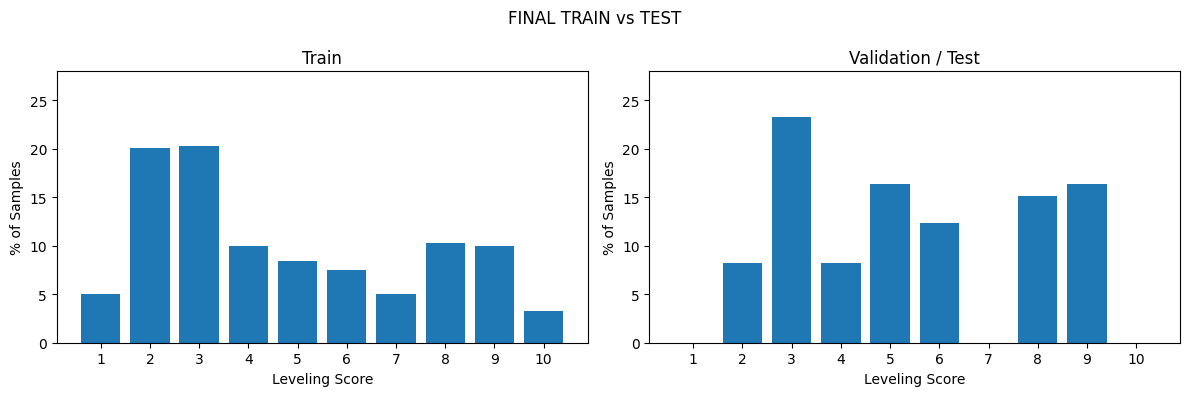


FOLD 1: TRAIN vs VALIDATION
    Train %  Test %
1       4.2     8.3
2      23.0     8.3
3      21.3    16.7
4      10.5     8.3
5       8.4     8.3
6       5.2    16.7
7       4.2     8.3
8      10.8     8.3
9      10.5     8.3
10      2.1     8.3


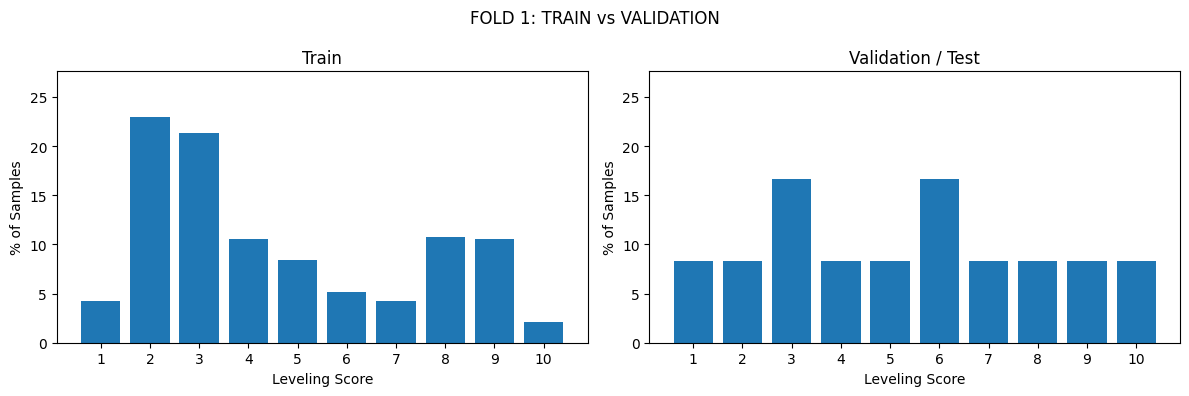


FOLD 2: TRAIN vs VALIDATION
    Train %  Test %
1       6.3     0.0
2      14.7    41.1
3      17.8    30.1
4      12.6     0.0
5      10.5     0.0
6       9.4     0.0
7       6.3     0.0
8      10.8     8.2
9       7.3    20.5
10      4.2     0.0


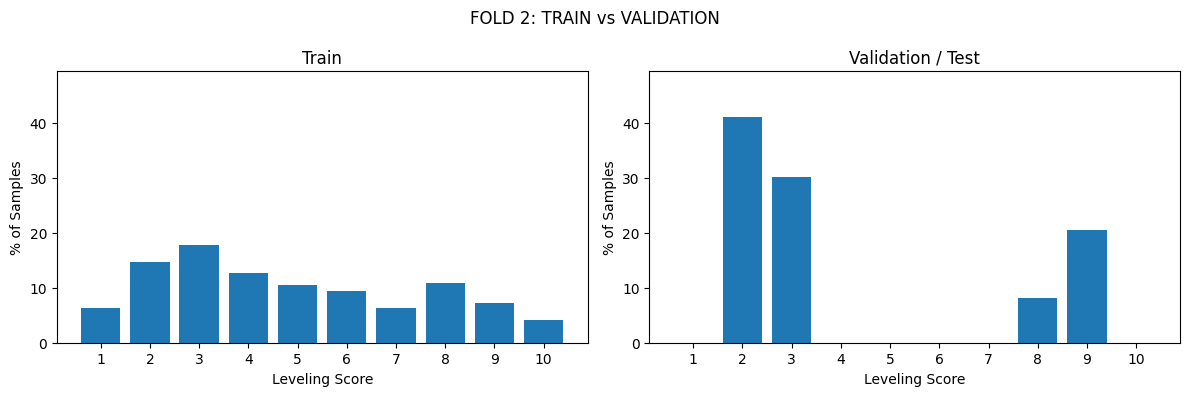


FOLD 3: TRAIN vs VALIDATION
    Train %  Test %
1       6.2     0.0
2      22.8     8.6
3      20.1    21.4
4       7.3    21.4
5       8.3     8.6
6       9.3     0.0
7       5.2     4.3
8       8.3    18.6
9       9.3    12.9
10      3.1     4.3


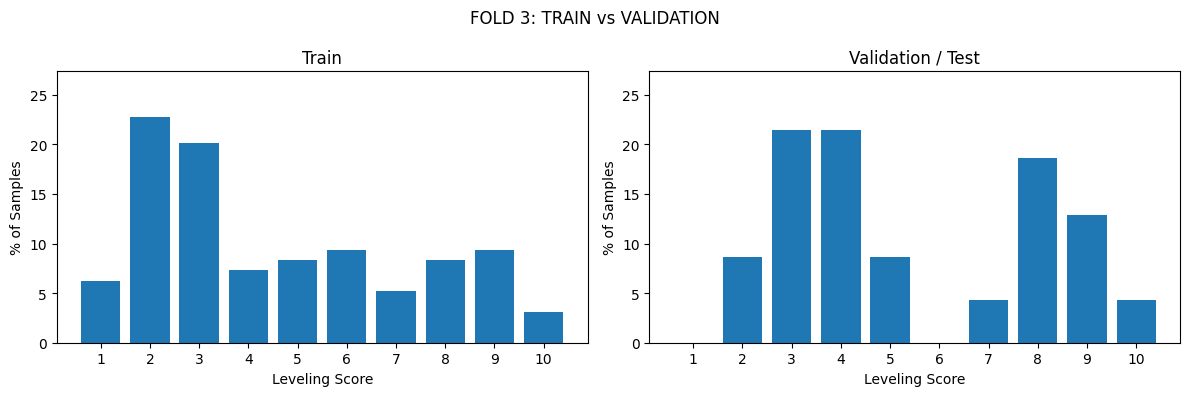


FOLD 4: TRAIN vs VALIDATION
    Train %  Test %
1       4.2     8.3
2      20.9    16.7
3      23.3     8.3
4       9.4    12.5
5       6.3    16.7
6       4.2    20.8
7       6.3     0.0
8       8.7    16.7
9      12.5     0.0
10      4.2     0.0


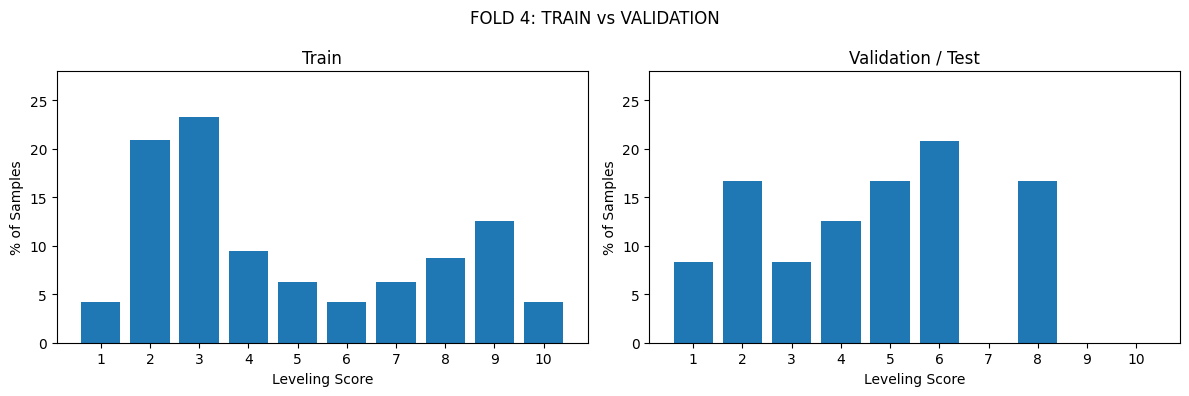


FOLD 5: TRAIN vs VALIDATION
    Train %  Test %
1       4.2     8.3
2      18.8    25.0
3      19.2    25.0
4      10.5     8.3
5       8.4     8.3
6       9.4     0.0
7       3.1    12.5
8      12.9     0.0
9      10.5     8.3
10      3.1     4.2


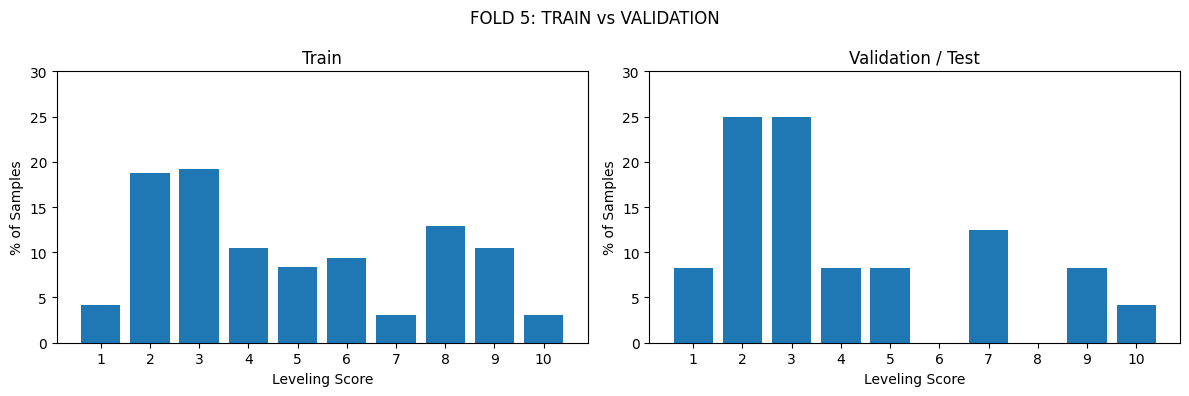

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import GroupKFold

# ==========================================
# PLOT PERCENT DISTRIBUTIONS
# ==========================================

def plot_percent_distribution(train_scores, test_scores, title):

    train_counts = pd.Series(train_scores).value_counts().sort_index()
    test_counts = pd.Series(test_scores).value_counts().sort_index()

    all_scores = sorted(
        set(train_counts.index).union(set(test_counts.index))
    )

    train_counts = train_counts.reindex(all_scores, fill_value=0)
    test_counts = test_counts.reindex(all_scores, fill_value=0)

    train_pct = train_counts / train_counts.sum() * 100
    test_pct = test_counts / test_counts.sum() * 100

    df = pd.DataFrame({
        "Train %": train_pct.round(1),
        "Test %": test_pct.round(1)
    })

    print("\n" + "=" * 60)
    print(title)
    print(df)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(df.index.astype(str), df["Train %"])
    axes[0].set_title("Train")
    axes[0].set_ylabel("% of Samples")
    axes[0].set_xlabel("Leveling Score")
    axes[0].set_ylim(0, max(df.max()) * 1.2)

    axes[1].bar(df.index.astype(str), df["Test %"])
    axes[1].set_title("Validation / Test")
    axes[1].set_ylabel("% of Samples")
    axes[1].set_xlabel("Leveling Score")
    axes[1].set_ylim(0, max(df.max()) * 1.2)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


# ==========================================
# FINAL TRAIN vs TEST
# ==========================================

plot_percent_distribution(
    y_train_real,
    y_test,
    "FINAL TRAIN vs TEST"
)


# ==========================================
# CV FOLDS
# ==========================================

gkf = GroupKFold(n_splits=5)

for fold, (train_idx_cv, val_idx_cv) in enumerate(
    gkf.split(X_train_real, y_train_real, groups_train)
):

    y_train_fold = y_train_real[train_idx_cv]
    y_val_fold = y_train_real[val_idx_cv]

    plot_percent_distribution(
        y_train_fold,
        y_val_fold,
        f"FOLD {fold+1}: TRAIN vs VALIDATION"
    )

In [ ]:
#
# We can see from the above cell towards the beginning of the notebook we have uneven distribution of data.
# This can pose a challenge because if the model sees one score more than others it can perfom well on those scores
# but poorly on rare scores. To confirm this is what is happening, we need to straify the data based on the current
# distribution we have, and then report the mae by score. We expect to see the model performs well on frequent scores and 
# poorly on less frequent scores. 
# these things will be investigated in the next notebook.